In [108]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pop_tools

In [109]:
from analysis import open_deficit_tracer_experiment, open_true_curve, open_deficit_tracer_curve

In [110]:
def get_colors(ids):
    cmap = plt.get_cmap("Paired")
    n = len(ids)
    return {id_: cmap(i % cmap.N) for i, id_ in enumerate(ids)}

## 12 selected polygons

In [111]:
suffix = "all"
ids = ["000", "001", "002", "150", "151", "152", "350", "351", "352", "651", "652", "653"]
all_ids = [f"{i:03d}" for i in range(0, 690)]

In [112]:
colors = get_colors(ids)

In [113]:
def _add_coastlines_and_gridlines(ax):    
    # Add coastlines and land
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    
    # Gridlines with labels only on left and bottom
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        x_inline=False,
        y_inline=False
    )
    gl.top_labels = False
    gl.right_labels = False

In [114]:
def _plot_polygons(ax, suffix, mode, ids, color_map):
    ds = open_deficit_tracer_experiment(suffix=suffix, first_file=True)

    if mode == "dor":
        forcing_varname = "DELTADIC"

    elif mode == "oae":
        forcing_varname = "DELTAALK"
        
    # Initialize mask with zeros for ocean
    mask = xr.full_like(ds[f"{forcing_varname}{ids[0]}_FORCING"].isel(time=0), 0, dtype=int)
    
    # Assign each polygon a unique integer
    for i, polygon_id in enumerate(ids):
        mask += xr.where(
            ds[f"{forcing_varname}{polygon_id}_FORCING"].isel(time=0) > 0,
            i + 1,
            0
        )

    # Set land cells (KMT==0) to NaN
    mask = mask.where(ds.KMT > 0, np.nan)

    # Colors: first entry is ocean (0), then polygon colors, land (NaN) handled via set_bad
    colors = ["white"] + [color_map[i] for i in ids]
    cmap = ListedColormap(colors)

    # Norm for discrete values: 0 (ocean), 1..N polygons
    bounds = np.arange(0, len(ids) + 2) - 0.5
    norm = BoundaryNorm(bounds, ncolors=len(colors))

    grid = pop_tools.get_grid("POP_gx1v7")
    
    ax.pcolormesh(
        grid.TLONG,
        grid.TLAT,
        mask,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree()
    )

    _add_coastlines_and_gridlines(ax)


In [115]:
_CENTROID_CACHE = {}


def _polygon_centroids(suffix, mode):
    """
    Area-weighted footprint centroid (lat, lon) for every polygon, from the
    forcing fields of the deficit-tracer run. Cached per (suffix, mode) so the
    690 footprints are read only once.
    """
    key = (suffix, mode)
    if key not in _CENTROID_CACHE:
        ds = open_deficit_tracer_experiment(suffix=suffix, first_file=True)
        fv = "DELTADIC" if mode == "dor" else "DELTAALK"
        grid = pop_tools.get_grid("POP_gx1v7")
        tlat = grid.TLAT.values
        tlon = grid.TLONG.values
        tarea = ds.TAREA.values

        cents = {}
        for k in range(690):
            name = f"{fv}{k:03d}_FORCING"
            if name not in ds:
                continue
            m = ds[name].isel(time=0).values > 0
            if not m.any():
                continue
            w = tarea[m]
            w = w / w.sum()
            lat = float((tlat[m] * w).sum())
            lon_rad = np.deg2rad(tlon[m])
            lon = np.degrees(np.arctan2((np.sin(lon_rad) * w).sum(),
                                        (np.cos(lon_rad) * w).sum())) % 360.0
            cents[f"{k:03d}"] = (lat, float(lon))
        _CENTROID_CACHE[key] = cents
    return _CENTROID_CACHE[key]


# dot-size mapping: steep power curve so small vs large divergences contrast
# sharply. _DOT_MIN keeps tiny dots visible; _DOT_MAX sets the largest marker.
_DOT_MIN, _DOT_MAX, _DOT_GAMMA = 3.0, 150.0, 1.8


def _scatter_divergence(ax, suffix, mode, polygon_ids, divergences,
                        divergence_signs, top_polygons, poly_color_map,
                        pos_color=None, neg_color=None,
                        dot_min=_DOT_MIN, dot_max=_DOT_MAX):
    """
    One dot per polygon on the map `ax`, sized by divergence magnitude.
    Marker shape encodes the sign of the net error (CDR - Truth):
      △  (^) CDR > Truth  (positive error)
      ▽  (v) CDR < Truth  (negative error)

    If pos_color/neg_color are given, all markers are filled with those colors
    (ignoring top/non-top distinction). Otherwise top-N polygons are filled
    with their Set3 colour and the rest are hollow black.
    """
    cents = _polygon_centroids(suffix, mode)
    dp = [p for p in polygon_ids if p in cents]
    lat = np.array([cents[p][0] for p in dp])
    lon = np.array([cents[p][1] for p in dp])
    val = np.array([divergences[p] for p in dp], dtype=float)
    sign = np.array([divergence_signs[p] for p in dp], dtype=float)

    # ramp size with divergence magnitude; reference is min of top-N (or global max)
    ref = min(divergences[p] for p in top_polygons) if top_polygons else max(divergences.values())
    frac = np.clip(val / ref, 0, 1) ** _DOT_GAMMA
    size = dot_min + (dot_max - dot_min) * frac
    is_pos = sign >= 0

    if pos_color is not None or neg_color is not None:
        for marker, mask_sign, color in [
            ("^", is_pos,  pos_color or "none"),
            ("v", ~is_pos, neg_color or "none"),
        ]:
            if mask_sign.any():
                ax.scatter(lon[mask_sign], lat[mask_sign], s=size[mask_sign],
                           marker=marker, facecolor=color,
                           edgecolors="black", linewidths=0.6, alpha=0.8,
                           transform=ccrs.PlateCarree(), zorder=4)
    else:
        is_top = np.array([p in top_polygons for p in dp])
        for marker, mask_sign in [("^", is_pos), ("v", ~is_pos)]:
            mask_other = mask_sign & ~is_top
            if mask_other.any():
                ax.scatter(lon[mask_other], lat[mask_other], s=size[mask_other],
                           marker=marker, facecolor="none",
                           edgecolors="black", linewidths=0.6, alpha=0.8,
                           transform=ccrs.PlateCarree(), zorder=4)
            mask_top = mask_sign & is_top
            if mask_top.any():
                top_colors = [poly_color_map[p] for p, t in zip(dp, mask_top) if t]
                ax.scatter(lon[mask_top], lat[mask_top], s=size[mask_top],
                           marker=marker, c=top_colors,
                           edgecolors="black", linewidths=0.9,
                           transform=ccrs.PlateCarree(), zorder=6)

In [116]:
def plot_polygons(suffix, mode, ids, color_map, title="Polygons", legend_kwargs={"loc": "upper center", "bbox_to_anchor": (0.5, -0.1), "ncol": 4}):
    
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": ccrs.PlateCarree()})

    _plot_polygons(ax, suffix, mode, ids, color_map)
    
    # --- Add legend ---
    legend_handles = []
    for i, polygon_id in enumerate(ids):
        legend_handles.append(Patch(facecolor=color_map[polygon_id], edgecolor="black", label=f"Polygon {polygon_id}"))

    ax.legend(
        handles=legend_handles,
        **legend_kwargs
    )      
    ax.set_title(title)
    return fig

In [71]:
mode = "oae"
suffix = "all-oae-daily"

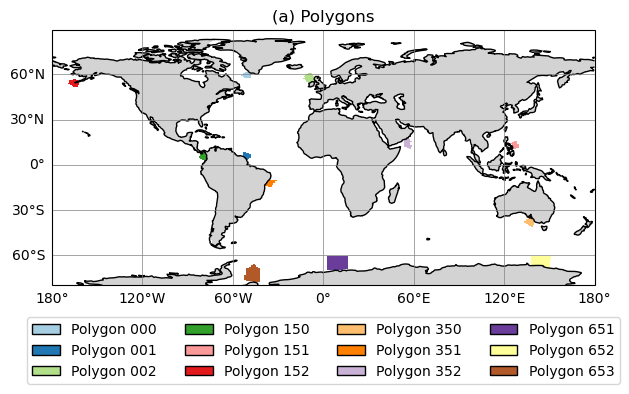

In [11]:
fig = plot_polygons(suffix, mode, ids, colors, title="(a) Polygons")

In [33]:
fig.savefig(
    "figures/polygons.png",
    dpi=300,
    bbox_inches="tight",
)

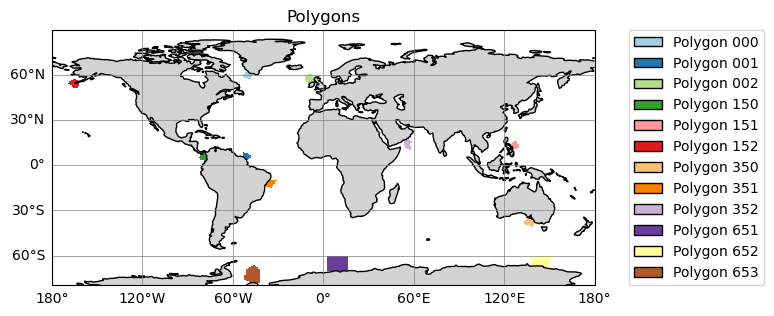

In [13]:
legend_kwargs={"loc": "center left", "bbox_to_anchor": (1.05, 0.5), "ncol": 1}
fig = plot_polygons(suffix, mode, ids, colors, legend_kwargs=legend_kwargs)

In [14]:
fig.savefig(
    "figures/polygons_legend_right.png",
    dpi=300,
    bbox_inches="tight",
)

Conversion factor:
$$
1 nmol = 10^{-9} mol
$$
Mass of CO₂ per mole: 44 g/mol

Mass of 1 mmol:
$$
    10^{-9} \cdot 44 g = 4.4 \cdot 10^{-8} g = 4.4 \cdot 10^{-17} kt
$$

In [117]:
factor = 4.4e-17

def add_month_boundary_vline(ax, x_years):
    """Dashed vertical line at ~Feb 1 of year 0.

    Curves are monthly and the first sample is for mid-January (even if its
    timestamp says end of January), so Feb 1 sits midway between the first two
    samples. `x_years` is the curve's x-coordinate (elapsed time in years).
    """
    x_years = np.asarray(x_years, dtype=float)
    xv = 0.5 * (x_years[0] + x_years[1])
    ax.axvline(xv, color="k", linestyle="--", linewidth=1)

In [118]:
def _compare_curves(axs, polygon_ids, mode, suffix, normalized=True, colors=colors, labels=["(b)", "(c)"], relative=False):
    """
    Compares true uptake curves against deficit tracer curves, plotting into
    a pair of pre-existing axes `axs` (efficiency/uptake curves in axs[0],
    difference curves in axs[1]) instead of creating a new figure. See
    `compare_curves` for a version that creates its own figure.
    """
    # Default color cycle
    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    x_years = None
    for i, p_id in enumerate(polygon_ids):
        label = f"ID: {p_id}"
        # Safely pick color
        if colors is None:
            color = default_colors[i % len(default_colors)]
        elif isinstance(colors, dict):
            color = colors.get(p_id, default_colors[i % len(default_colors)])
        else:  # list-like
            color = colors[i % len(colors)]
            
        
        # Data Retrieval
        ds_true = open_true_curve(p_id, mode)
        ds_tilde = open_deficit_tracer_curve(p_id, suffix)
        
        # Calculation Logic
        if normalized:
            curve = (ds_true.uptake / ds_true.forcing).squeeze()
            curve_tilde = ds_tilde.uptake / ds_tilde.forcing
            if mode == "dor":
                curve = -1 * curve
                curve_tilde = -1 * curve_tilde
        else:
            curve = (ds_true.uptake).squeeze() * factor
            curve_tilde = ds_tilde.uptake * factor

        # Plotting
        axs[0].plot(curve_tilde.elapsed_time / 365, curve_tilde, 
            lw=4, color="k", linestyle="dashed", label=label
        )
        
        axs[0].plot(curve.elapsed_time / 365, curve, 
            lw=2, color=color,
            label="_none"
        )
        


        # Find the minimum length
        min_len = min(len(curve), len(curve_tilde))
        # Truncate arrays
        x = curve.elapsed_time[:min_len] / 365
        x_years = x.values
        true_vals = curve[:min_len].values
        y = curve_tilde[:min_len].values - true_vals   # CDR Tracer - Truth
        if relative:
            y = 100 * np.divide(y, true_vals, out=np.full_like(y, np.nan), where=true_vals != 0)

        # Plot
        axs[1].plot(x, y, lw=2, color=color, label=label)
        axs[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    diff_prefix = "Relative error" if relative else "Absolute error"
    diff_suffix = r"$(\tilde{\mathcal{E}} - \mathcal{E})/\mathcal{E} \times 100$" if relative else r"$\tilde{\mathcal{E}} - \mathcal{E}$"
    if normalized:
        title = f"{mode.upper()} efficiency"  
        title_diff = f"{diff_prefix} in {mode.upper()} efficiencies: {diff_suffix}"
        axs[0].set_ylim([0, 1.1])  
    else:
        title = r"Total CO$_2$ uptake" 
        title_diff = f"{diff_prefix} in CO$_2$ uptake"
        axs[0].set_ylabel(r"[ktCO$_2$]")
        if not relative:
            axs[1].set_ylabel(r"[ktCO$_2$]")
    if relative:
        axs[1].set_ylabel("%")
    # Styling
    # axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    for ax in axs:
        ax.grid(True, which="both", linestyle="--", linewidth=0.5, color="white")
        ax.set_xlabel("Years")
        ax.set_facecolor("#f0f0f0")
        if x_years is not None:
            add_month_boundary_vline(ax, x_years)
    
    axs[0].set_title(f"{labels[0]} {title}")
    axs[1].set_title(f"{labels[1]} {title_diff}")

In [119]:
def compare_curves(polygon_ids, mode, suffix, normalized=True, colors=colors, labels=["", ""], relative=False):
    """
    Compares true uptake curves against deficit tracer curves.
    Accepts a list of up to 4 polygon_id's. 
    'colors' can be a list of colors; if None, uses a standard cycle.
    'relative', if True, shows the difference panel as a relative error
    (CDR Tracer - Truth) / Truth, in percent, instead of the absolute error.
    """
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    _compare_curves(axs, polygon_ids, mode, suffix, normalized=normalized, colors=colors, labels=labels, relative=relative)

    plt.tight_layout()
    return fig

In [120]:
def plot_summary_figure(ids, colors, suffix_dor, suffix_oae, relative):
    """
    Combines the DOR/OAE efficiency curves and their relative errors into a
    single 2x2 figure, with a shared y-axis within each row:
        row 0: (b) DOR efficiency,      (c) OAE efficiency
        row 1: (d) DOR relative error,  (e) OAE relative error
    """
    fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharey="row")

    _compare_curves(
        [axs[0, 0], axs[1, 0]], ids, "dor", suffix_dor,
        normalized=True, colors=colors, labels=["(b)", "(d)"], relative=relative,
    )
    _compare_curves(
        [axs[0, 1], axs[1, 1]], ids, "oae", suffix_oae,
        normalized=True, colors=colors, labels=["(c)", "(e)"], relative=relative,
    )

    for ax in axs[:, 1]:
        ax.tick_params(labelleft=False)

    plt.tight_layout()
    return fig

### Efficiency and error

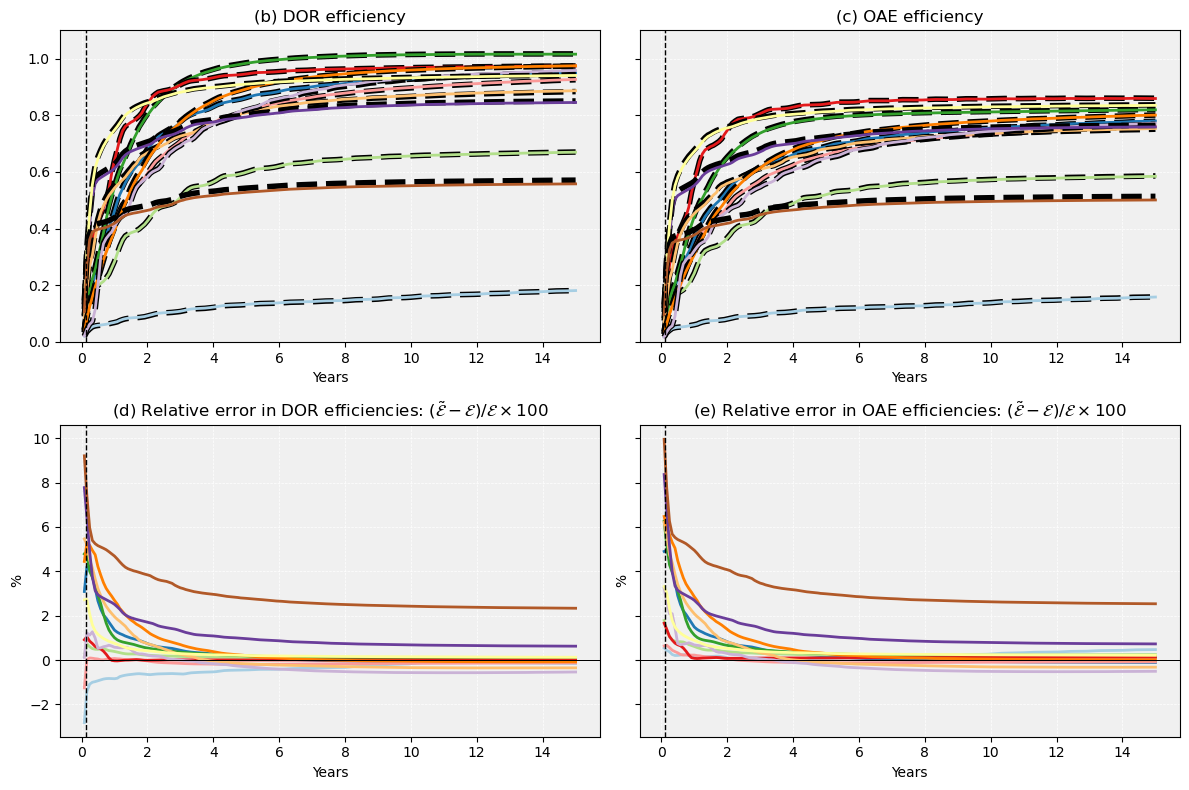

In [29]:
fig = plot_summary_figure(ids, colors, suffix_dor="all-dor-daily", suffix_oae="all-oae-daily", relative=True)

In [30]:
fig.savefig(
    "figures/summary_polygons_efficiency_relative.png",
    dpi=300,
    bbox_inches="tight",
)

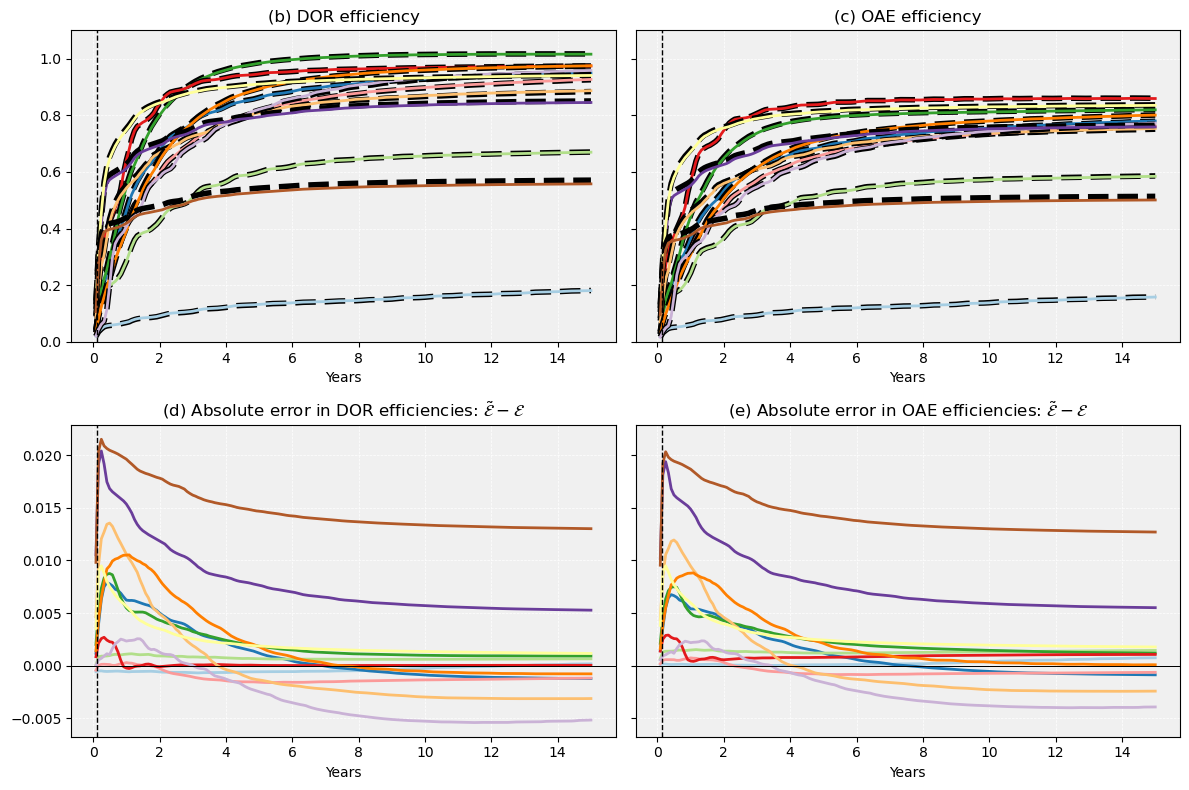

In [31]:
fig = plot_summary_figure(ids, colors, suffix_dor="all-dor-daily", suffix_oae="all-oae-daily", relative=False)

In [32]:
fig.savefig(
    "figures/summary_polygons_efficiency_absolute.png",
    dpi=300,
    bbox_inches="tight",
)

### Total uptake and error

In [30]:
mode = "oae"
suffix = "all-oae-daily"

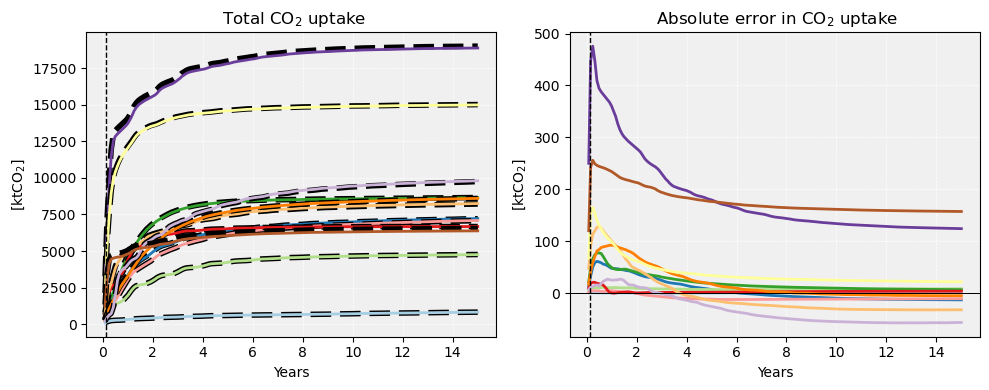

In [31]:
fig = compare_curves(ids, mode, suffix, normalized=False, labels=["", ""])

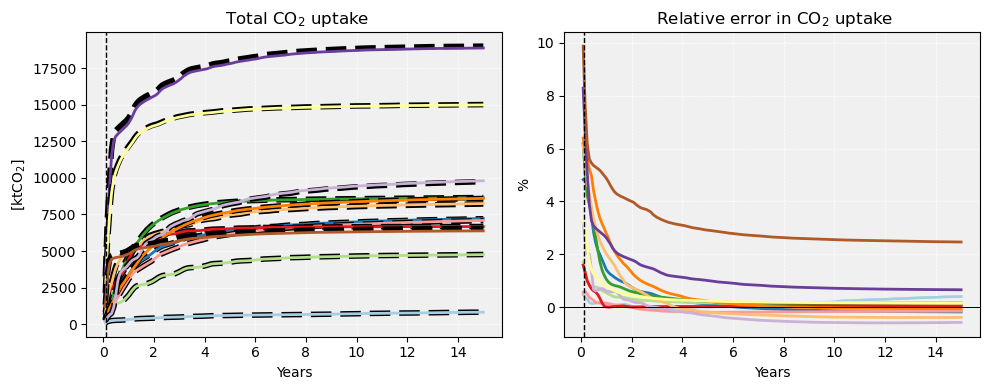

In [32]:
fig = compare_curves(ids, mode, suffix, normalized=False, relative=True, labels=["", ""])

## All polygons

In [23]:
suffix = "all-oae-daily"
mode = "oae"

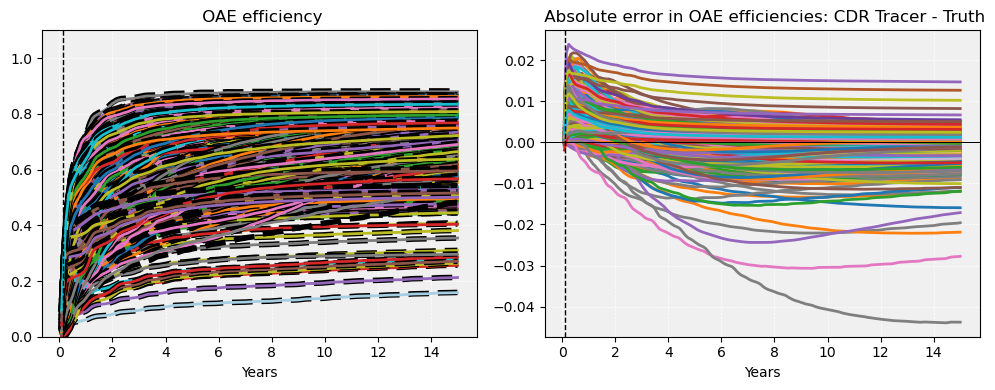

In [24]:
fig = compare_curves(all_ids, mode, suffix, normalized=True, labels=["", ""])

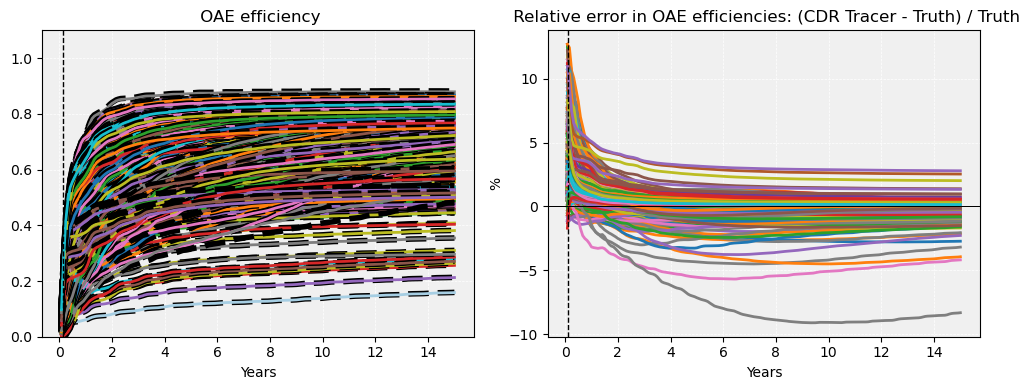

In [25]:
fig = compare_curves(all_ids, mode, suffix, normalized=True, labels=["", ""], relative=True)

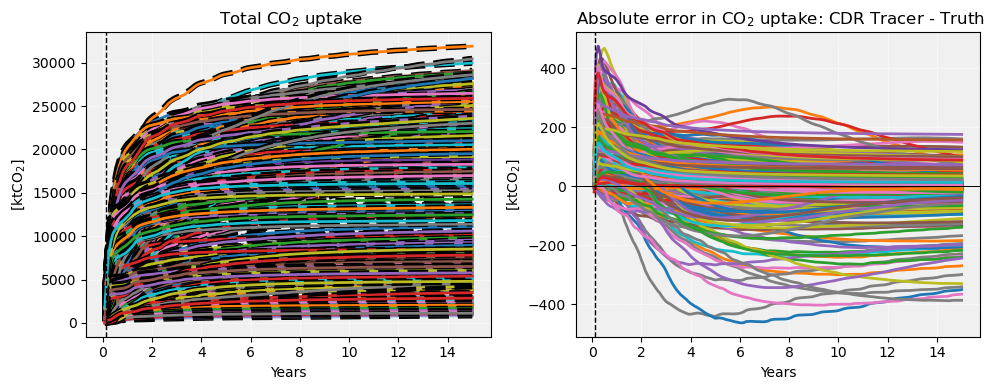

In [26]:
fig = compare_curves(all_ids, mode, suffix, normalized=False, labels=["", ""])

## Highlight polygons that diverge the most

**Bad-curve definition.** A "bad curve" is a polygon whose deficit-tracer efficiency curve
diverges most from the truth.

```
efficiency(t) = uptake(t) / forcing(t)          # normalized=True; ×(-1) for DOR
rel_err(t)    = 100 · (truth − tracer) / truth
relerr_divergence = Σ_t |rel_err(t)|            # == compare_difference_curves(..., relative=True)
absdiv            = Σ_t |truth − tracer|        # == compare_difference_curves(..., relative=False)

# marker shape on map encodes the sign of (tracer − truth), weighted as for the divergence metric:
sign_cumulative = sign( Σ_t [tracer(t) − truth(t)] / truth(t) )   # △ if > 0, ▽ if ≤ 0  (relative=True)
sign_final      = sign( [tracer(t) − truth(t)] / truth(t)  at last t )               # △ if > 0, ▽ if ≤ 0
```

`relerr_divergence` is the default `TARGET` here (largest **relative** error). `absdiv` is
available too; the two ranks correlate at ρ ≈ 0.94.


In [121]:
def _compute_polygon_data(polygon_ids, mode, suffix, normalized, relative, top_n):
    """Load curves and compute divergences, cumulative/final signs, and color map."""
    _base = list(plt.get_cmap("Set3").colors)
    _base[8] = "#e5c494"
    cmap = ListedColormap([_base[i % len(_base)] for i in range(top_n)])

    divergences = {}
    signs_cumulative = {}
    signs_final = {}
    curves_diff = {}
    curves_true = {}

    for p_id in polygon_ids:
        ds_true = open_true_curve(p_id, mode)
        ds_tilde = open_deficit_tracer_curve(p_id, suffix)

        if normalized:
            curve = (ds_true.uptake / ds_true.forcing).squeeze()
            curve_tilde = ds_tilde.uptake / ds_tilde.forcing
            if mode == "dor":
                curve = -1 * curve
                curve_tilde = -1 * curve_tilde
        else:
            curve = ds_true.uptake * factor
            curve_tilde = ds_tilde.uptake * factor

        min_len = min(len(curve), len(curve_tilde))
        x = curve.elapsed_time[:min_len] / 365
        true_vals = curve[:min_len].values
        diff = curve_tilde[:min_len].values - true_vals
        if relative:
            diff = 100 * np.divide(diff, true_vals, out=np.full_like(diff, np.nan), where=true_vals != 0)

        curves_diff[p_id] = (x, diff)
        curves_true[p_id] = (x, true_vals)
        divergences[p_id] = np.nansum(np.abs(diff))
        signs_cumulative[p_id] = np.sign(np.nansum(diff))
        valid = diff[~np.isnan(diff)]
        signs_final[p_id] = np.sign(valid[-1]) if len(valid) else 0.0

    top_polygons = sorted(divergences, key=divergences.get, reverse=True)[:top_n]
    poly_color_map = {p_id: cmap(i) for i, p_id in enumerate(top_polygons)}

    return dict(
        divergences=divergences,
        signs_cumulative=signs_cumulative,
        signs_final=signs_final,
        curves_diff=curves_diff,
        curves_true=curves_true,
        top_polygons=top_polygons,
        poly_color_map=poly_color_map,
        x_years=next(iter(curves_diff.values()))[0],
    )


def _draw_map_panel(ax, suffix, mode, polygon_ids, pdata, sign_mode, title,
                    color_top=True, legend_loc="upper left",
                    pos_color=None, neg_color=None,
                    dot_min=_DOT_MIN, dot_max=_DOT_MAX):
    """Render one divergence scatter map with △/▽ markers into ax."""
    signs = pdata["signs_cumulative"] if sign_mode == "cumulative" else pdata["signs_final"]
    top_polygons = pdata["top_polygons"] if color_top else []
    poly_color_map = pdata["poly_color_map"] if color_top else {}
    _add_coastlines_and_gridlines(ax)
    ax.set_global()
    _scatter_divergence(ax, suffix, mode, polygon_ids, pdata["divergences"],
                        signs, top_polygons, poly_color_map,
                        pos_color=pos_color, neg_color=neg_color,
                        dot_min=dot_min, dot_max=dot_max)
    ax.set_title(title)
    sign_label = "at end" if sign_mode == "final" else "net"
    shape_handles = [
        plt.Line2D([0], [0], marker="^", linestyle="none", markersize=7,
                   markerfacecolor=pos_color or "none", markeredgecolor="black",
                   label=f"CDR Tracer > Truth ({sign_label})"),
        plt.Line2D([0], [0], marker="v", linestyle="none", markersize=7,
                   markerfacecolor=neg_color or "none", markeredgecolor="black",
                   label=f"CDR Tracer < Truth ({sign_label})"),
    ]
    ax.legend(handles=shape_handles, loc=legend_loc, fontsize=10,
              framealpha=0.8, handletextpad=0.4)


def _draw_polygon_legend(ax, pdata, legend_y=1.2):
    """Draw the top-N polygon colour legend into an invisible axes."""
    legend_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="none", markersize=9,
                   markerfacecolor=pdata["poly_color_map"][p], markeredgecolor="black",
                   label=f"Polygon {p}")
        for p in pdata["top_polygons"]
    ]
    ax.legend(handles=legend_handles, loc="upper center", ncol=6, fontsize=10,
              frameon=True, borderaxespad=0.0, bbox_to_anchor=(0.5, legend_y))


def compare_difference_curves(polygon_ids, mode, suffix, normalized=True, top_n=12, show_stats=True, relative=False, vmin=None, vmax=None, show_efficiency=True, sign_mode="cumulative"):
    """
    Difference curves (CDR Tracer - Truth) for a set of polygons, with the
    top-N most-diverging polygons highlighted in colour (the rest grey).

    Layout: the two line panels are on top, the polygon map below them, and
    the colour -> polygon legend directly below the map.

    Parameters
    ----------
    polygon_ids : list of str
    suffix : str
    normalized : bool, default True
    top_n : int
    show_stats : bool, default True
    relative : bool, default False
    vmin, vmax : float, optional
    show_efficiency : bool, default True
    sign_mode : {"cumulative", "final"}, default "cumulative"
    """
    pdata = _compute_polygon_data(polygon_ids, mode, suffix, normalized, relative, top_n)
    curves_diff = pdata["curves_diff"]
    curves_true = pdata["curves_true"]
    top_polygons = pdata["top_polygons"]
    poly_color_map = pdata["poly_color_map"]
    x_years = pdata["x_years"]

    # ---- figure layout ----
    if show_efficiency:
        fig = plt.figure(figsize=(15, 13))
        gs = fig.add_gridspec(3, 2, height_ratios=[1, 1.9, 0.11], hspace=0.3, wspace=0.1)
        ax_err = fig.add_subplot(gs[0, 0])
        ax_eff = fig.add_subplot(gs[0, 1])
        ax_map = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
        ax_leg = fig.add_subplot(gs[2, :]); ax_leg.axis("off")
    else:
        fig = plt.figure(figsize=(12, 12))
        gs = fig.add_gridspec(3, 1, height_ratios=[1, 1.9, 0.11], hspace=0.25)
        ax_err = fig.add_subplot(gs[0, 0])
        ax_map = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
        ax_leg = fig.add_subplot(gs[2, 0]); ax_leg.axis("off")
        ax_eff = None

    # ---- (a) error curves ----
    ax_err.set_axisbelow(True)
    ax_err.grid(True, ls="--", lw=0.5, color="white")
    for p_id in polygon_ids:
        if p_id not in top_polygons:
            x, diff = curves_diff[p_id]
            ax_err.plot(x, diff, lw=1, color="gray", alpha=0.5, zorder=1)
    for p_id in top_polygons:
        x, diff = curves_diff[p_id]
        ax_err.plot(x, diff, lw=2, color=poly_color_map[p_id], zorder=2)

    if show_stats:
        common_len = min(len(d) for _, d in curves_diff.values())
        x_common = next(iter(curves_diff.values()))[0][:common_len]
        diff_stack = np.stack([d[:common_len] for _, d in curves_diff.values()])
        mean_diff = np.nanmean(diff_stack, axis=0)
        std_diff = np.nanstd(diff_stack, axis=0)
        ax_err.plot(x_common, mean_diff, lw=2.5, color="k", zorder=3, label="Mean (all polygons)")
        ax_err.plot(x_common, mean_diff - std_diff, lw=2, color="k", ls="--", zorder=3, label="$\\pm$ 1 SD (all polygons)")
        ax_err.plot(x_common, mean_diff + std_diff, lw=2, color="k", ls="--", zorder=3)
        ax_err.legend(loc="best", fontsize=10)

    ax_err.axhline(0, color="black", lw=0.5)
    add_month_boundary_vline(ax_err, x_years)
    ax_err.set_xlabel("Years")
    if relative:
        ax_err.set_ylabel("%")
    diff_prefix = "Relative error" if relative else "Absolute error"
    diff_suffix = r"$(\tilde{\mathcal{E}} - \mathcal{E})/\mathcal{E} \times 100$" if relative else r"$\tilde{\mathcal{E}} - \mathcal{E}$"
    ax_err.set_title(f"(a) {diff_prefix} in {mode.upper()} efficiencies: {diff_suffix}")
    ax_err.set_facecolor("#f0f0f0")
    if vmin is not None or vmax is not None:
        ax_err.set_ylim(bottom=vmin, top=vmax)

    # ---- (b) truth efficiency curves ----
    if ax_eff is not None:
        ax_eff.set_axisbelow(True)
        ax_eff.grid(True, ls="--", lw=0.5, color="white")
        for p_id in polygon_ids:
            if p_id not in top_polygons:
                xx, yy = curves_true[p_id]
                ax_eff.plot(xx, yy, lw=1, color="gray", alpha=0.3, zorder=1)
        for p_id in top_polygons:
            xx, yy = curves_true[p_id]
            ax_eff.plot(xx, yy, lw=2, color=poly_color_map[p_id], zorder=2)
        add_month_boundary_vline(ax_eff, x_years)
        math = r"$\mathcal{E}$"
        c_quantity = f"{mode.upper()} efficiency {math}" if normalized else r"CO$_2$ uptake"
        ax_eff.set_xlabel("Years")
        ax_eff.set_ylabel("" if normalized else r"[ktCO$_2$]")
        ax_eff.set_title(f"(b) {c_quantity} (truth)")
        ax_eff.set_facecolor("#f0f0f0")

    # ---- (c) map ----
    q = f"{mode.upper()} efficiency" if normalized else f"CO$_2$ uptake ({mode.upper()})"
    _draw_map_panel(ax_map, suffix, mode, polygon_ids, pdata, sign_mode,
                    f"(c) Polygons with the largest divergence in {q}")
    _draw_polygon_legend(ax_leg, pdata)

    return fig

In [124]:
def plot_sign_mode_maps(polygon_ids, mode, suffix, normalized=True, top_n=12, relative=False):
    """
    Two maps stacked vertically comparing how the marker sign (△/▽) changes
    depending on whether the sign is derived from the cumulative or final error.
    Markers are red (△ CDR > truth) or blue (▽ CDR < truth); size encodes
    divergence magnitude.

      (a) Cumulative sign: sign of Σ_t [(tracer − truth) / truth]
      (b) Final-timestep sign: sign of [(tracer − truth) / truth] at last t
    """
    pdata = _compute_polygon_data(polygon_ids, mode, suffix, normalized, relative, top_n)

    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.25)
    ax_a = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
    ax_b = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())

    q = f"{mode.upper()} efficiency" if normalized else f"CO$_2$ uptake ({mode.upper()})"
    kw = dict(color_top=False, legend_loc="upper right",
              pos_color="red", neg_color="blue",
              dot_min=10, dot_max=400)
    _draw_map_panel(ax_a, suffix, mode, polygon_ids, pdata, "cumulative",
                    f"(a) Cumulative sign",
                    **kw)
    _draw_map_panel(ax_b, suffix, mode, polygon_ids, pdata, "final",
                    f"(b) Final-timestep sign",
                    **kw)

    return fig

### OAE

In [21]:
suffix = "all-oae-daily"
mode = "oae"

#### Absolute error

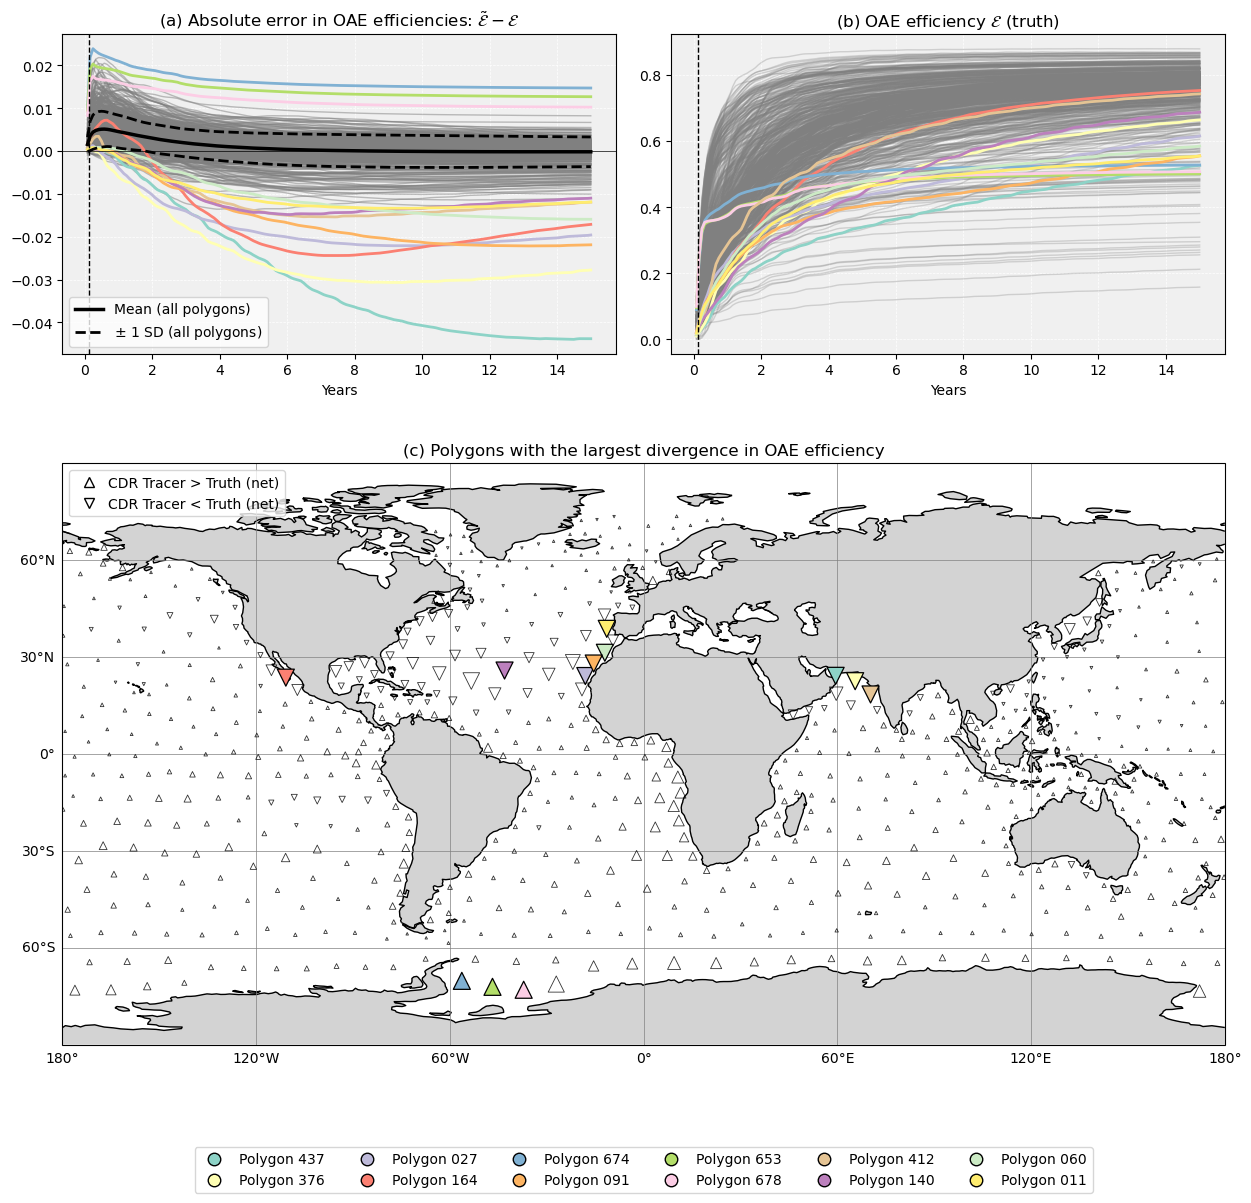

In [22]:
fig = compare_difference_curves(all_ids, mode, suffix)

In [23]:
fig.savefig(
    "figures/largest_divergences_oae.png",
    dpi=300,
    bbox_inches="tight",
)

#### Relative error

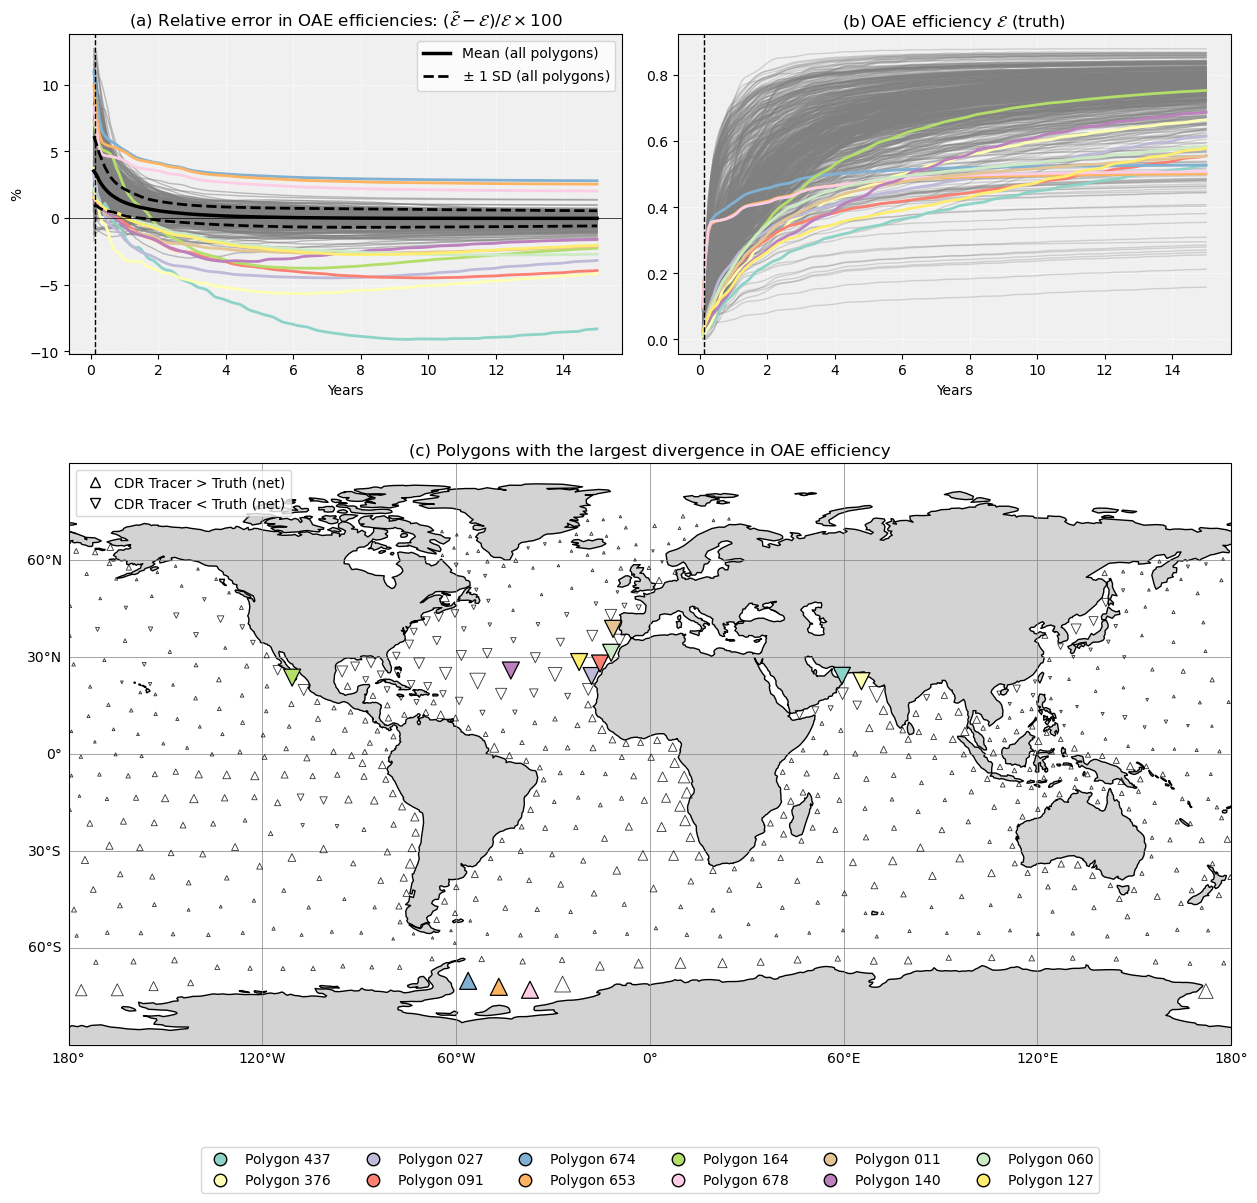

In [24]:
fig = compare_difference_curves(all_ids, mode, suffix, relative=True)

In [25]:
fig.savefig(
    "figures/largest_divergences_relative_oae.png",
    dpi=300,
    bbox_inches="tight",
)

### DOR

In [28]:
suffix = "all-dor-daily"
mode = "dor"

#### Absolute error

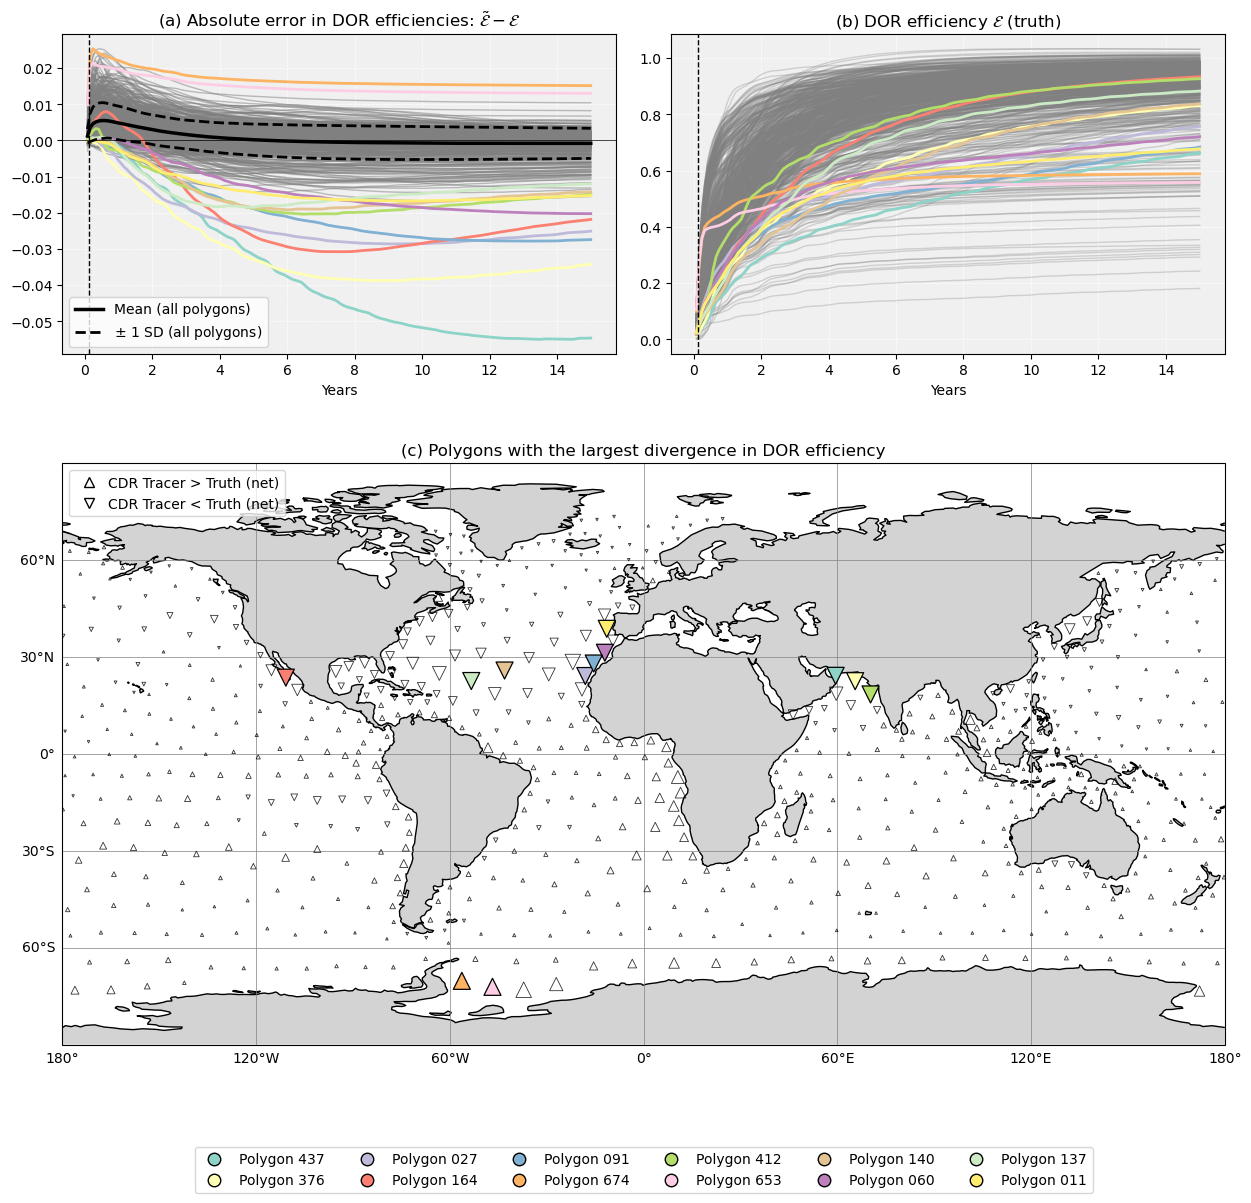

In [29]:
fig = compare_difference_curves(all_ids, mode, suffix)

In [30]:
fig.savefig(
    "figures/largest_divergences_dor.png",
    dpi=300,
    bbox_inches="tight",
)

#### Relative error

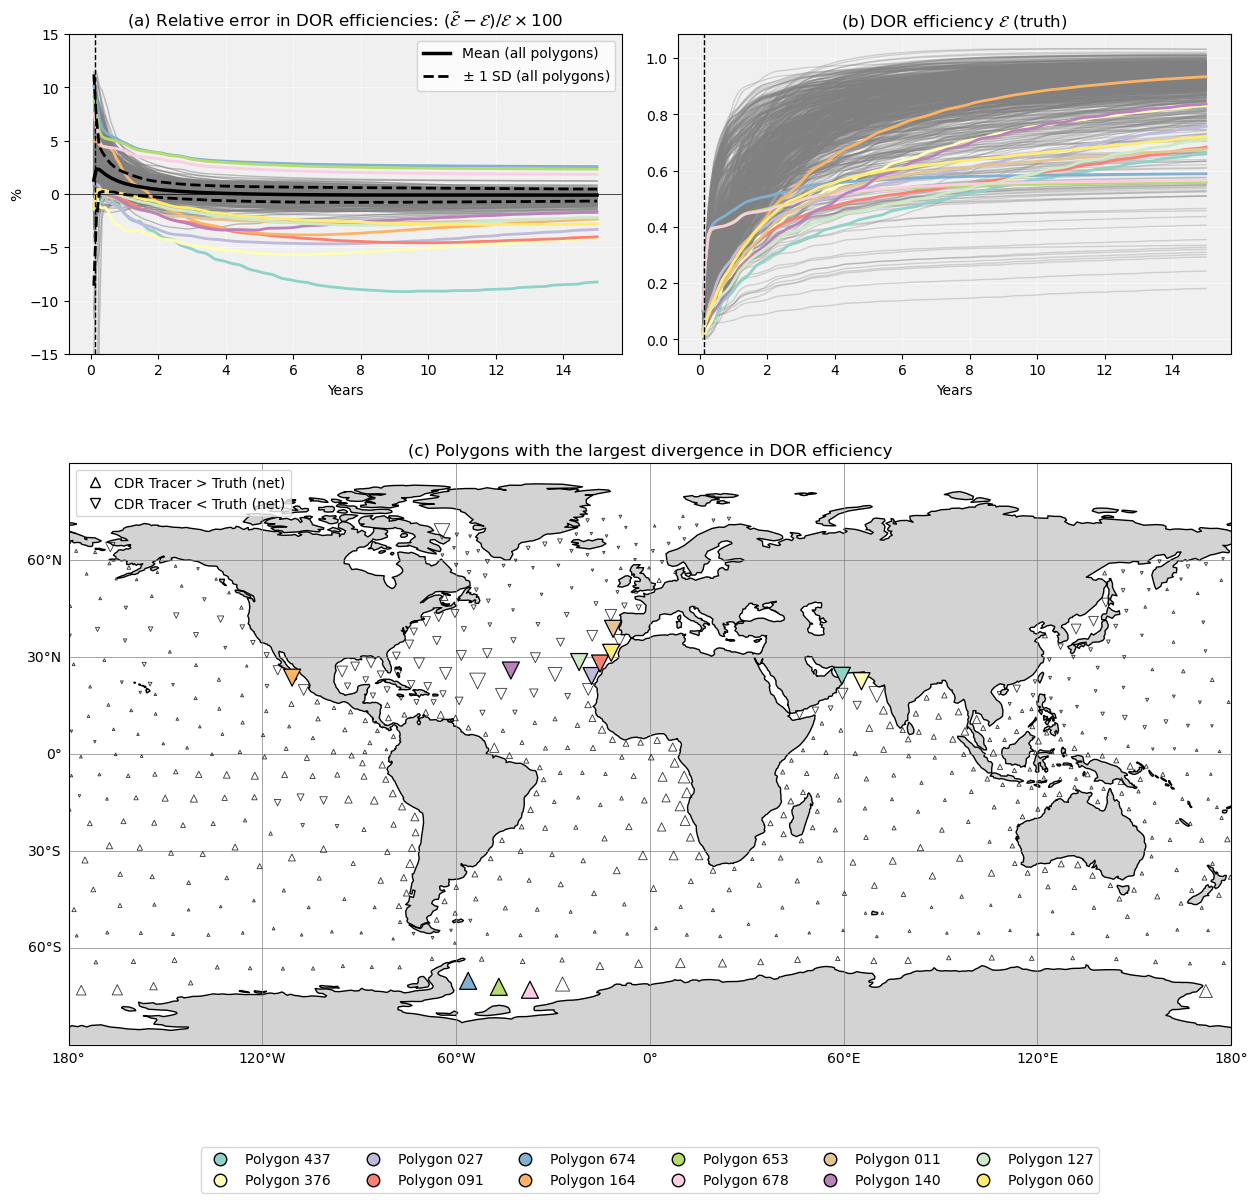

In [31]:
fig = compare_difference_curves(all_ids, mode, suffix, relative=True, vmin=-15, vmax=15)

In [32]:
fig.savefig(
    "figures/largest_divergences_relative_dor.png",
    dpi=300,
    bbox_inches="tight",
)

### Net vs. final sign

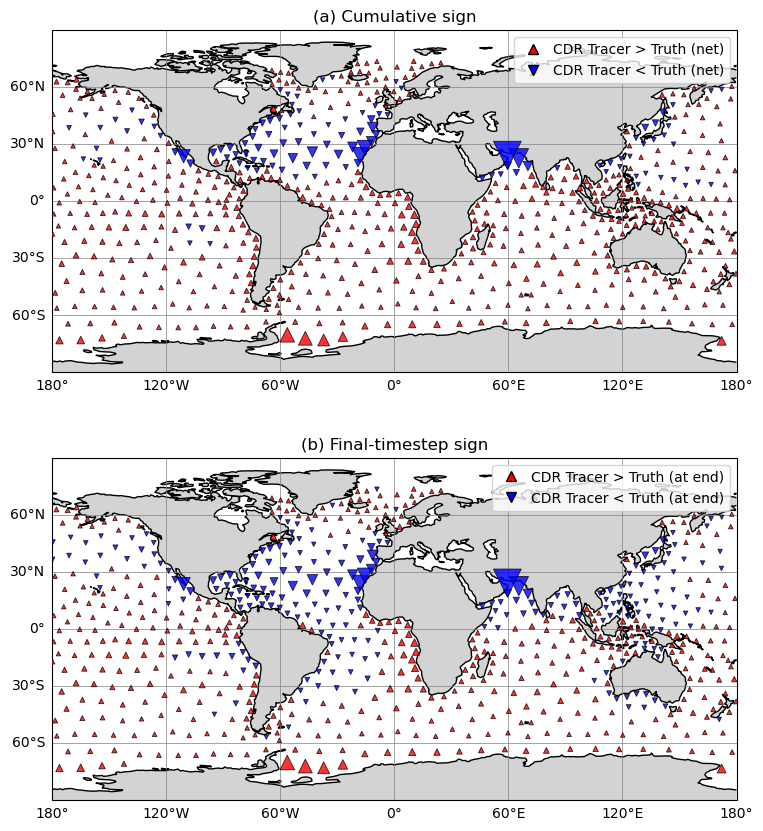

In [125]:
fig = plot_sign_mode_maps(all_ids, mode="oae", suffix="all-oae-daily", relative=True)

In [126]:
fig.savefig(
    "figures/sign_mode_maps_oae.png",
    dpi=300,
    bbox_inches="tight",
)

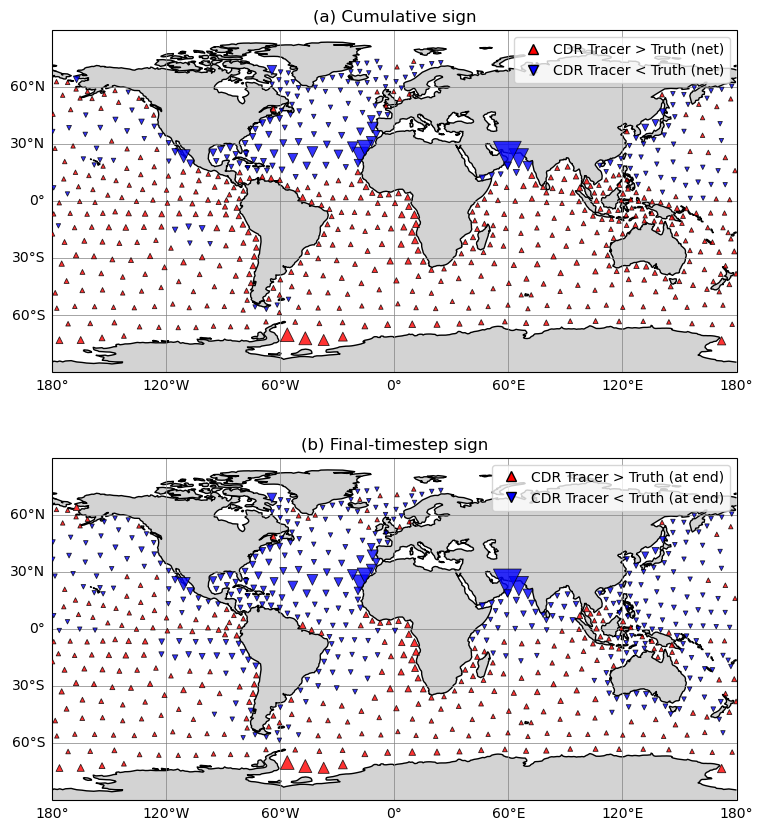

In [127]:
fig = plot_sign_mode_maps(all_ids, mode="dor", suffix="all-dor-daily", relative=True)

In [128]:
fig.savefig(
    "figures/sign_mode_maps_dor.png",
    dpi=300,
    bbox_inches="tight",
)

## Query final relative efficiency error for a single polygon

In [10]:
def query_final_rel_err(polygon_id, mode, suffix):
    """Return the final relative efficiency error (CDR tracer - truth) / truth * 100 [%]."""
    ds_true = open_true_curve(polygon_id, mode)
    ds_tilde = open_deficit_tracer_curve(polygon_id, suffix)

    curve = (ds_true.uptake / ds_true.forcing).squeeze()
    curve_tilde = ds_tilde.uptake / ds_tilde.forcing
    if mode == "dor":
        curve = -1 * curve
        curve_tilde = -1 * curve_tilde

    min_len = min(len(curve), len(curve_tilde))
    true_vals = curve[:min_len].values
    diff = curve_tilde[:min_len].values - true_vals
    rel_err = 100 * np.divide(diff, true_vals, out=np.full_like(diff, np.nan), where=true_vals != 0)
    return float(rel_err[~np.isnan(rel_err)][-1])

In [11]:
polygon_id = "651"

err_oae = query_final_rel_err(polygon_id, mode="oae", suffix="all-oae-daily")
err_dor = query_final_rel_err(polygon_id, mode="dor", suffix="all-dor-daily")

print(f"Polygon {polygon_id} — final relative efficiency error:")
print(f"  OAE: {err_oae:.4f} %")
print(f"  DOR: {err_dor:.4f} %")

Polygon 651 — final relative efficiency error:
  OAE: 0.7260 %
  DOR: 0.6238 %


In [12]:
polygon_id = "653"

err_oae = query_final_rel_err(polygon_id, mode="oae", suffix="all-oae-daily")
err_dor = query_final_rel_err(polygon_id, mode="dor", suffix="all-dor-daily")

print(f"Polygon {polygon_id} — final relative efficiency error:")
print(f"  OAE: {err_oae:.4f} %")
print(f"  DOR: {err_dor:.4f} %")

Polygon 653 — final relative efficiency error:
  OAE: 2.5346 %
  DOR: 2.3334 %
